In [8]:
import cv2
import glob
import numpy as np
import os
from google.colab.patches import cv2_imshow

In [9]:

class AdvancedStitcher:
    def __init__(self, folder):
        self.folder = folder
        self.images = []

    def load_and_preprocess(self, scale=1.0):
        print(f"[INFO] Loading images from: {self.folder}")

        # Load ALL common formats
        image_paths = glob.glob(os.path.join(self.folder, "*"))
        image_paths = [p for p in image_paths if p.lower().endswith(('.jpg', '.jpeg', '.png'))]

        print(f"[DEBUG] Found {len(image_paths)} candidate files")

        if not image_paths:
            print("[ERROR] No image files found!")
            return

        loaded = 0

        for path in sorted(image_paths):
            img = cv2.imread(path)

            if img is None:
                print(f"[WARNING] Failed to load: {path}")
                continue

            if scale != 1.0:
                img = cv2.resize(img, None, fx=scale, fy=scale)

            self.images.append(img)
            loaded += 1

        print(f"[INFO] Successfully loaded {loaded} images")

    def stitch_advanced(self, mode="PANORAMA"):
        if len(self.images) < 2:
            print("[ERROR] Need at least 2 images to stitch")
            return None

        print("[INFO] Starting stitching...")

        if mode == "PANORAMA":
            stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
        else:
            stitcher = cv2.Stitcher_create(cv2.Stitcher_SCANS)

        status, stitched = stitcher.stitch(self.images)

        if status != cv2.Stitcher_OK:
            print(f"[ERROR] Stitching failed. Status: {status}")
            return None

        print("[INFO] Stitching successful")
        return stitched


In [10]:
folder_path = "/content/sample_data/data"

In [11]:
print("[CHECK] Folder exists:", os.path.exists(folder_path))
print("[CHECK] Files:", os.listdir(folder_path))

[CHECK] Folder exists: True
[CHECK] Files: ['25.jpeg', '28.jpeg', '16.jpeg', '20.jpeg', '8.jpeg', '9.jpeg', '30.jpeg', '2.jpeg', '5.jpeg', '26.jpeg', '10.jpeg', '11.jpeg', '27.jpeg', '14.jpeg', '23.jpeg', '1.jpeg', '7.jpeg', '24.jpeg', '17.jpeg', '6.jpeg', '3.jpeg', '18.jpeg', '29.jpeg', '4.jpeg', '12.jpeg', '22.jpeg', '21.jpeg', '19.jpeg', '13.jpeg', '15.jpeg']


In [12]:
my_stitcher = AdvancedStitcher('/content/sample_data/data')

[INFO] Loading images from: /content/sample_data/data
[DEBUG] Found 30 candidate files
[INFO] Successfully loaded 30 images
[INFO] Starting stitching...
[INFO] Stitching successful
[INFO] Saved as stitched_output.jpg


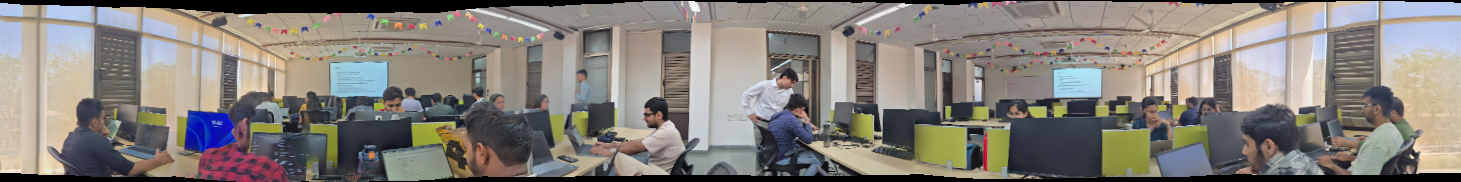

In [13]:
my_stitcher.load_and_preprocess(scale=0.2)

result = my_stitcher.stitch_advanced(mode="PANORAMA")

if result is not None:
    cv2.imwrite("stitched_output.jpg", result)
    print("[INFO] Saved as stitched_output.jpg")

    # Display (Colab-friendly)
    from google.colab.patches import cv2_imshow
    cv2_imshow(result)